# Unemployment, Oil Prices & Motor Vehicle Theft (1986–2025)

## Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.grid': True,
})

In [2]:
URL_UNRATE = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/UNRATE.csv"
URL_OIL    = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/MCOILWTICO.csv"
URL_THEFT  = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Final/Motor%20Vehicle%20Theft%20Reported%20by%20Population_04-29-2026%20(1).csv"


## Load & Clean

In [15]:
YEAR_START, YEAR_END = 1986, 2025

# U.S. population by year (millions) — for theft rate per 100k
population = {
    1986:240.13,1987:242.29,1988:244.50,1989:246.82,1990:249.62,
    1991:252.98,1992:256.51,1993:259.92,1994:263.13,1995:266.28,
    1996:269.39,1997:272.65,1998:275.85,1999:279.04,2000:282.16,
    2001:284.97,2002:287.63,2003:290.11,2004:292.81,2005:295.52,
    2006:298.38,2007:301.23,2008:304.09,2009:306.77,2010:309.33,
    2011:311.72,2012:314.01,2013:316.20,2014:318.39,2015:320.74,
    2016:323.07,2017:325.15,2018:327.21,2019:328.24,2020:331.50,
    2021:332.03,2022:333.29,2023:334.91,2024:336.99,2025:339.00,
}

# Unemployment
unrate_raw = pd.read_csv(URL_UNRATE, parse_dates=['observation_date'])
unrate_raw = unrate_raw.rename(columns={'observation_date': 'date', 'UNRATE': 'value'})
unrate_raw = unrate_raw.set_index('date').resample('YE').mean()
unrate_raw.index = unrate_raw.index.year
unrate = unrate_raw[(unrate_raw.index >= YEAR_START) & (unrate_raw.index <= YEAR_END)]['value']

# Oil
oil_raw = pd.read_csv(URL_OIL, parse_dates=['observation_date'])
oil_raw = oil_raw.rename(columns={'observation_date': 'date', 'MCOILWTICO': 'value'})
oil_raw = oil_raw.set_index('date').resample('YE').mean()
oil_raw.index = oil_raw.index.year
oil = oil_raw[(oil_raw.index >= YEAR_START) & (oil_raw.index <= YEAR_END)]['value']

# Theft — unpivot from wide format, sum to annual, convert to rate per 100k
theft_raw = pd.read_csv(URL_THEFT)
theft_row = theft_raw[theft_raw['Series'] == 'United States Offenses'].drop(columns='Series').T.reset_index()
theft_row.columns = ['month_str', 'offenses']
theft_row['date'] = pd.to_datetime(theft_row['month_str'], format='%m-%Y')
theft_row['offenses'] = pd.to_numeric(theft_row['offenses'], errors='coerce')
theft_row = theft_row.set_index('date').resample('YE').sum()
theft_row.index = theft_row.index.year
theft_row = theft_row[(theft_row.index >= YEAR_START) & (theft_row.index <= YEAR_END)]
theft_row['population'] = theft_row.index.map(lambda y: population[y] * 1_000_000)
theft_rate = (theft_row['offenses'] / theft_row['population'] * 100_000).round(2)

# Merge
df = pd.DataFrame({'unrate': unrate, 'oil': oil, 'theft_rate': theft_rate}).dropna()
print(f"Dataset: {df.index.min()}–{df.index.max()}, {len(df)} years")
df.describe().round(2)


Dataset: 1986–2025, 40 years


,unrate,oil,theft_rate
count,40.00,40.00,40.00
mean,5.70,48.09,373.72
std,1.57,28.72,143.91
min,3.62,14.45,179.28
25%,4.58,20.60,233.89
50%,5.45,42.29,390.00
75%,6.34,69.07,480.77
max,9.61,99.57,639.98


## Chart 1 — Individual Trends

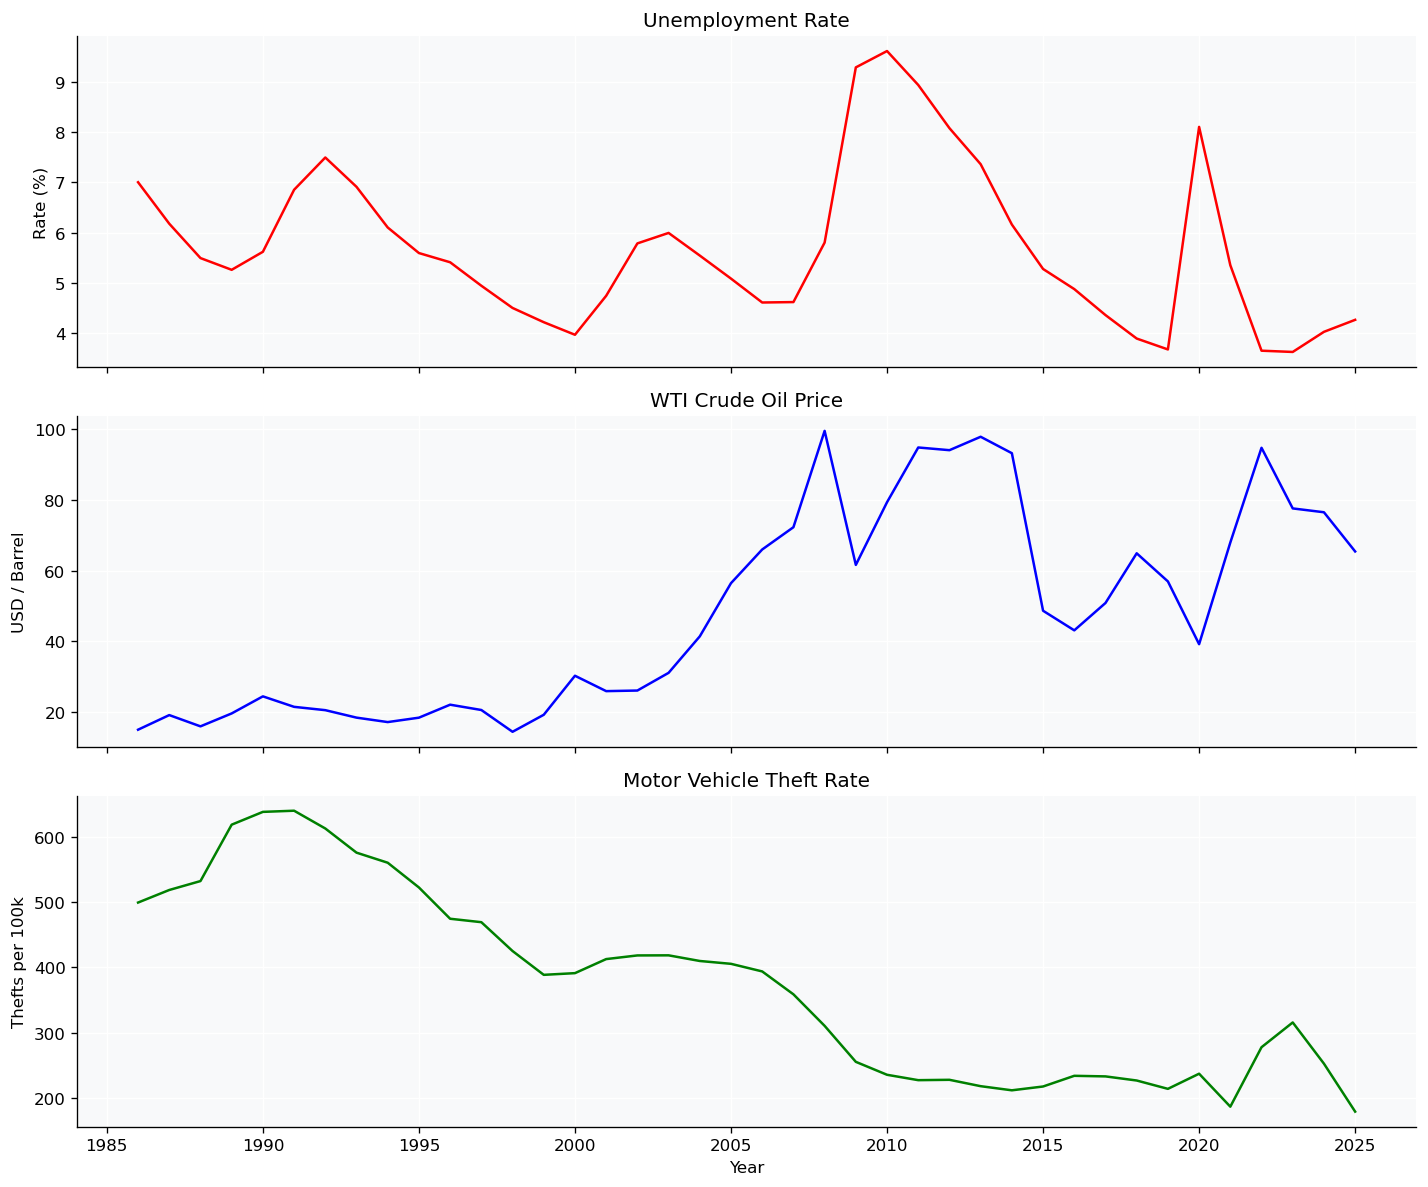

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df.index, df['unrate'], color='red')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('Unemployment Rate')

axes[1].plot(df.index, df['oil'], color='blue')
axes[1].set_ylabel('USD / Barrel')
axes[1].set_title('WTI Crude Oil Price')

axes[2].plot(df.index, df['theft_rate'], color='green')
axes[2].set_ylabel('Thefts per 100k')
axes[2].set_title('Motor Vehicle Theft Rate')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()


## Chart 2 — Normalized Overlay
All three variables scaled to 0–1 so they can be compared on one axis.

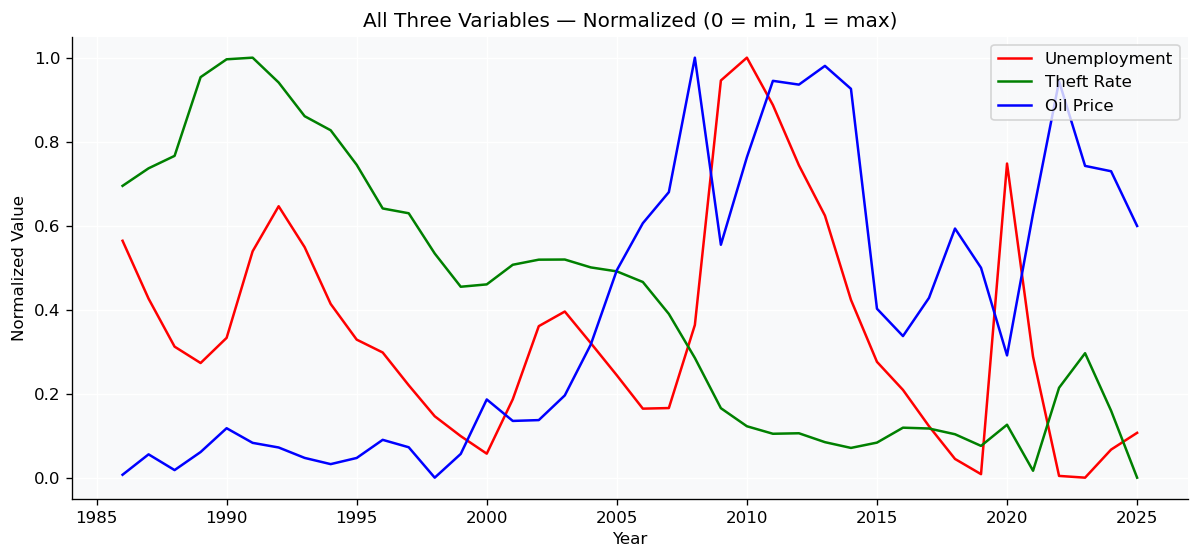

In [18]:
unrate_norm = (df['unrate']     - df['unrate'].min())     / (df['unrate'].max()     - df['unrate'].min())
oil_norm    = (df['oil']        - df['oil'].min())        / (df['oil'].max()        - df['oil'].min())
theft_norm  = (df['theft_rate'] - df['theft_rate'].min()) / (df['theft_rate'].max() - df['theft_rate'].min())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, unrate_norm, color='red',   label='Unemployment')
ax.plot(df.index, theft_norm,  color='green', label='Theft Rate')
ax.plot(df.index, oil_norm,    color='blue',  label='Oil Price')

ax.set_title('All Three Variables — Normalized (0 = min, 1 = max)')
ax.set_ylabel('Normalized Value')
ax.set_xlabel('Year')
ax.legend()
plt.show()


## Chart 3 — Oil Price vs. Theft Rate

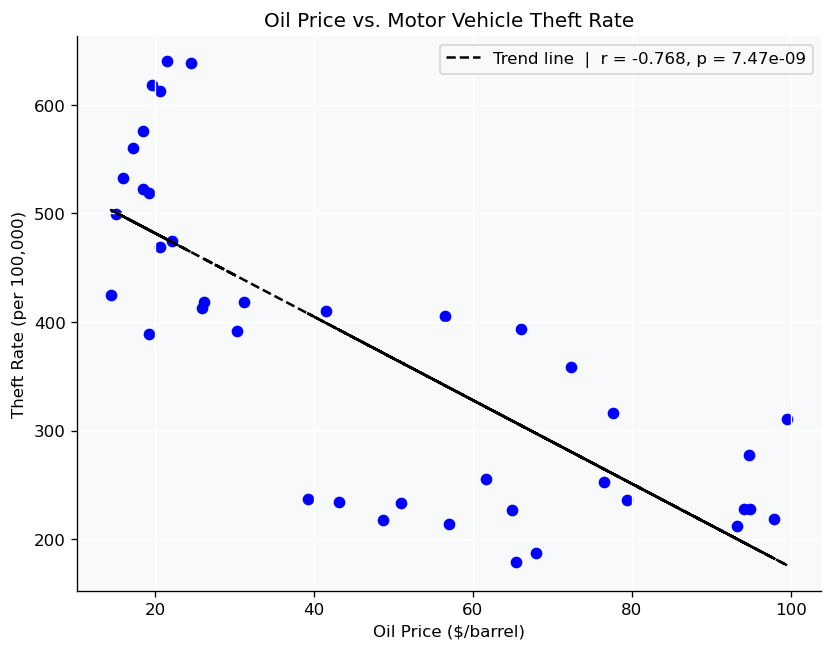

In [20]:
x = df['oil']
y = df['theft_rate']

slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='blue')
ax.plot(x, slope * x + intercept, color='black', ls='--', label=f'Trend line  |  r = {r:.3f}, p = {p:.3g}')

ax.set_xlabel('Oil Price ($/barrel)')
ax.set_ylabel('Theft Rate (per 100,000)')
ax.set_title('Oil Price vs. Motor Vehicle Theft Rate')
ax.legend()
plt.show()


## Chart 4 — Rolling 10-Year Correlation

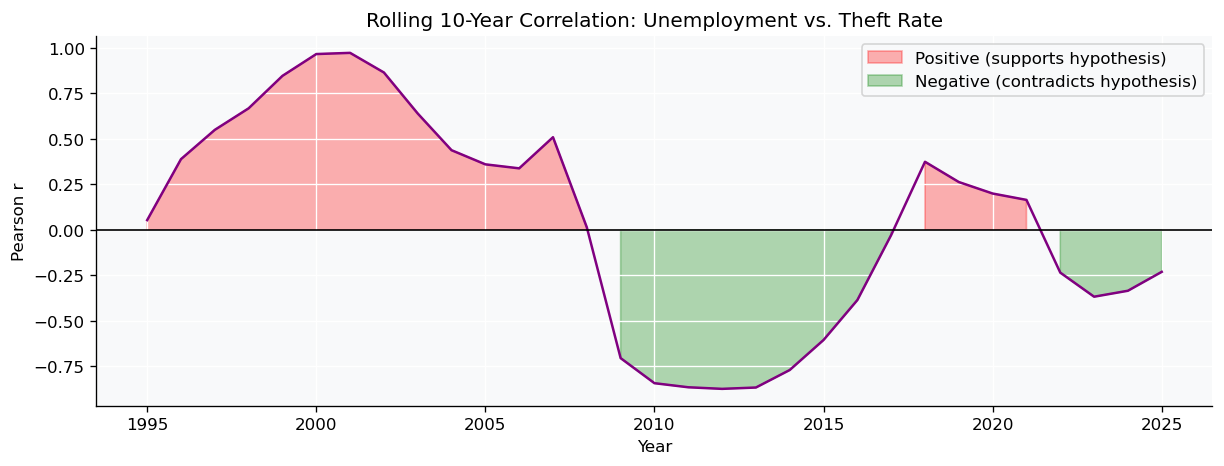

In [21]:
roll_r = df['unrate'].rolling(10).corr(df['theft_rate'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, roll_r, color='purple')
ax.axhline(0, color='black', lw=1)
ax.fill_between(df.index, roll_r, 0, where=roll_r >= 0, alpha=0.3, color='red',   label='Positive (supports hypothesis)')
ax.fill_between(df.index, roll_r, 0, where=roll_r < 0,  alpha=0.3, color='green', label='Negative (contradicts hypothesis)')

ax.set_title('Rolling 10-Year Correlation: Unemployment vs. Theft Rate')
ax.set_ylabel('Pearson r')
ax.set_xlabel('Year')
ax.legend()
plt.show()


## Chart 5 — Unemployment vs. Theft Rate
Our hypothesis predicts a positive correlation — the data shows otherwise.

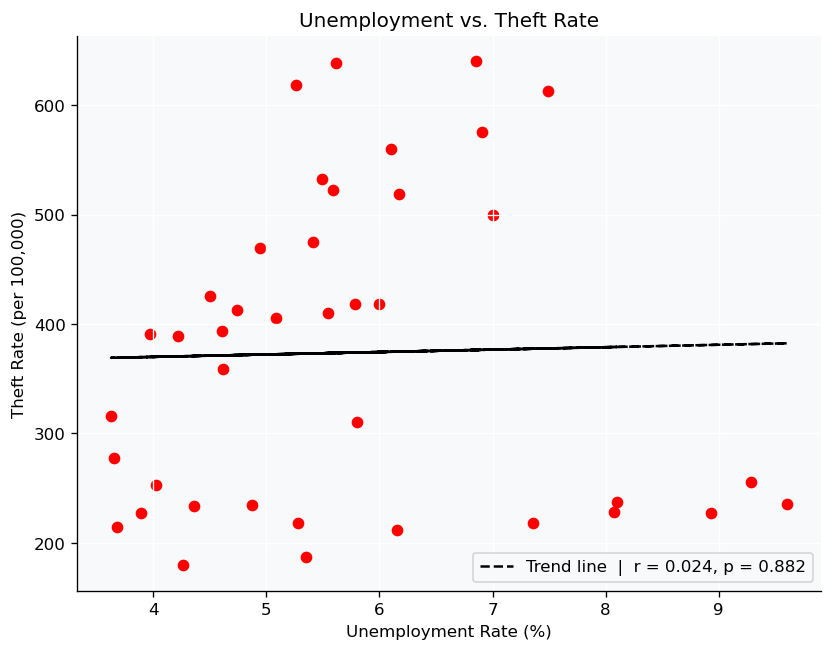

In [22]:
x = df['unrate']
y = df['theft_rate']

slope, intercept, r, p, _ = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='red')
ax.plot(x, slope * x + intercept, color='black', ls='--', label=f'Trend line  |  r = {r:.3f}, p = {p:.3g}')

ax.set_xlabel('Unemployment Rate (%)')
ax.set_ylabel('Theft Rate (per 100,000)')
ax.set_title('Unemployment vs. Theft Rate')
ax.legend()
plt.show()


## Chart 6 — Which Relationship Is Actually Significant?
All three pairwise correlations tested. Bar length = strength, color = significance.

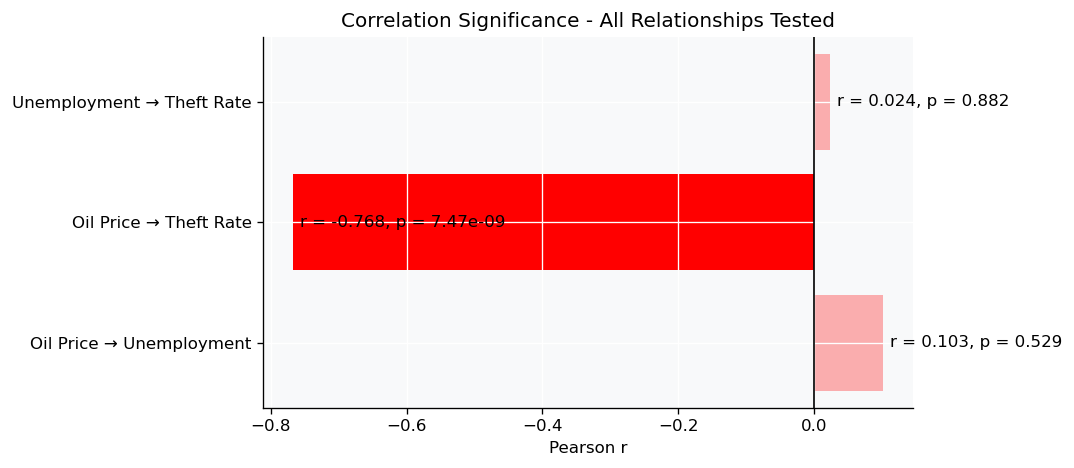

In [27]:
r1, p1 = stats.pearsonr(df['unrate'], df['theft_rate'])
r2, p2 = stats.pearsonr(df['oil'],    df['theft_rate'])
r3, p3 = stats.pearsonr(df['oil'],    df['unrate'])

labels = ['Unemployment → Theft Rate', 'Oil Price → Theft Rate', 'Oil Price → Unemployment']
r_vals = [r1, r2, r3]
p_vals = [p1, p2, p3]

fig, ax = plt.subplots(figsize=(9, 4))
for i in range(3):
    alpha  = 1.0 if p_vals[i] < 0.05 else 0.3
    ax.barh(i, r_vals[i], color='red', alpha=alpha)
    ax.text(r_vals[i] + 0.01, i, f'r = {r_vals[i]:.3f}, p = {p_vals[i]:.3g}', va='center')

ax.set_yticks(range(3))
ax.set_yticklabels(labels)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson r')
ax.set_title('Correlation Significance - All Relationships Tested')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

t = 1.80  |  p = 0.080


/var/folders/mt/w2zqkpqd1wj65bslf60hdsf40000gn/T/ipykernel_78564/2113436071.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([lo, hi], labels=['Low Unemployment', 'High Unemployment'])


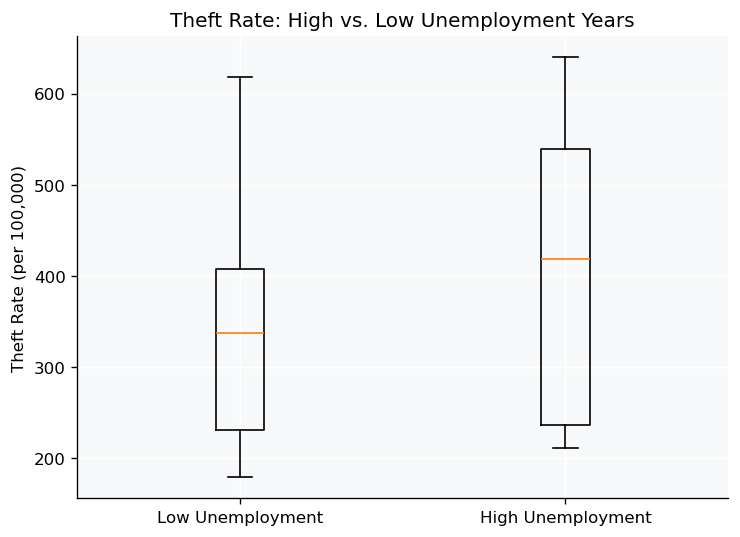

In [26]:
median_u = df['unrate'].median()
hi = df[df['unrate'] >= median_u]['theft_rate']
lo = df[df['unrate'] <  median_u]['theft_rate']

t_stat, p_val = stats.ttest_ind(hi, lo)

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([lo, hi], labels=['Low Unemployment', 'High Unemployment'])

ax.set_ylabel('Theft Rate (per 100,000)')
ax.set_title('Theft Rate: High vs. Low Unemployment Years')
print(f't = {t_stat:.2f}  |  p = {p_val:.3f}')
plt.show()